# P300 EEG -> Adaptive-LIF SNN classifier (fixed pipeline)

In [1]:
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
from scipy.io import loadmat
from scipy.signal import butter, filtfilt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    balanced_accuracy_score, classification_report,
    confusion_matrix, roc_auc_score
)
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

# ============================================================
# CONFIG
# ============================================================

DATA_ROOT = Path("../data")     # same as your original notebook — change only if needed
SUBJECT = "SBJ01"
SESSIONS = None                 # None = auto-discover and use ALL sessions for this subject

FS = 250
LOWCUT = 0.1
HIGHCUT = 20.0

N_HIDDEN = 64
DROPOUT = 0.3
BATCH_SIZE = 32
N_EPOCHS = 100
LR = 3e-3          # was 1e-3 — bumped since gradients over 350 steps were too weak to move the model
WEIGHT_DECAY = 1e-4
PATIENCE = 20
DOWNSAMPLE_FACTOR = 2  # 350 -> 175 timesteps: shortens the BPTT chain and roughly halves training time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


### 1. Data loading — ALL blocks, ALL sessions for the subject



In [2]:
def discover_sessions(subject_dir):
    return sorted(p for p in subject_dir.glob("S*") if (p / "Train").exists())


def load_session_train(session_dir):
    train_dir = session_dir / "Train"

    mat = loadmat(train_dir / "trainData.mat")
    data_vars = {k: v for k, v in mat.items() if not k.startswith("__")}
    eeg = list(data_vars.values())[0]                      # (channels, samples, epochs)
    X = np.transpose(eeg, (2, 0, 1)).astype(np.float32)     # (epochs, channels, samples)

    targets = np.loadtxt(train_dir / "trainTargets.txt", dtype=int).flatten()

    n_per_block = 80   # 10 runs x 8 objects, same as your original BLOCK_SIZE
    block_ids = np.arange(len(targets)) // n_per_block
    return X, targets, block_ids


def load_subject_epochs(data_root, subject, sessions=None):
    subject_dir = data_root / subject
    session_dirs = (
        discover_sessions(subject_dir) if sessions is None
        else [subject_dir / s for s in sessions]
    )

    all_X, all_y, all_groups = [], [], []
    for session_dir in session_dirs:
        X, y, block_ids = load_session_train(session_dir)
        groups = [f"{session_dir.name}_B{b}" for b in block_ids]
        all_X.append(X)
        all_y.append(y)
        all_groups.extend(groups)
        print(f"  {session_dir.name}: {X.shape[0]} epochs "
              f"({int((y == 1).sum())} target / {int((y == 0).sum())} non-target)")

    X = np.concatenate(all_X, axis=0)
    y = np.concatenate(all_y, axis=0)
    groups = np.array(all_groups)
    return X, y, groups


print(f"Loading all sessions for {SUBJECT} ...")
X_raw, y_all, groups = load_subject_epochs(DATA_ROOT, SUBJECT, SESSIONS)
print(f"\nTotal epochs: {X_raw.shape[0]}  "
      f"(target={int((y_all == 1).sum())}, non-target={int((y_all == 0).sum())})")

Loading all sessions for SBJ01 ...
  S01: 1600 epochs (200 target / 1400 non-target)
  S02: 1600 epochs (200 target / 1400 non-target)
  S03: 1600 epochs (200 target / 1400 non-target)
  S04: 1600 epochs (200 target / 1400 non-target)
  S05: 1600 epochs (200 target / 1400 non-target)
  S06: 1600 epochs (200 target / 1400 non-target)
  S07: 1600 epochs (200 target / 1400 non-target)

Total epochs: 11200  (target=1400, non-target=9800)


### 2. Preprocessing

Same band-pass filter, baseline correction (-200 to 0 ms), and per-channel z-score normalization as your original Phase 1 — just wrapped as a reusable function that handles the full epoch count.

In [3]:
def preprocess_eeg(X, fs=250, lowcut=0.1, highcut=20.0, order=4):
    nyq = fs / 2
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype="band")
    X_filt = filtfilt(b, a, X, axis=-1)

    baseline_samples = int(0.2 * fs)  # epoch starts at -200 ms
    baseline_mean = X_filt[:, :, :baseline_samples].mean(axis=2, keepdims=True)
    X_bc = X_filt - baseline_mean

    ch_mean = X_bc.mean(axis=2, keepdims=True)
    ch_std = X_bc.std(axis=2, keepdims=True)
    X_norm = (X_bc - ch_mean) / (ch_std + 1e-8)
    return X_norm.astype(np.float32)


print("Preprocessing (bandpass + baseline correction + z-score)...")
X_prep = preprocess_eeg(X_raw, FS, LOWCUT, HIGHCUT)
print("Preprocessed shape:", X_prep.shape)

Preprocessing (bandpass + baseline correction + z-score)...
Preprocessed shape: (11200, 8, 350)


### 2b. Signal-detection diagnostic — is there any P300 signal to learn at all?


In [4]:
from sklearn.metrics import roc_auc_score

t = np.arange(X_prep.shape[2]) / FS - 0.2   # epoch starts at -200 ms
p300_mask = (t >= 0.25) & (t <= 0.6)

p300_amplitude = X_prep[:, :, p300_mask].mean(axis=(1, 2))
diag_auc = roc_auc_score(y_all, p300_amplitude)
print(f"AUC of raw P300-window amplitude vs target label: {diag_auc:.3f}")
print("~0.5  = no detectable signal in this window/preprocessing -> check channels/timing first")
print(">0.6  = signal is present -> proceed, the model below should be able to find it")

AUC of raw P300-window amplitude vs target label: 0.553
~0.5  = no detectable signal in this window/preprocessing -> check channels/timing first
>0.6  = signal is present -> proceed, the model below should be able to find it


### 3. Temporal spike encoding


In [5]:
def rate_encode(X, seed=42):
    rng = np.random.default_rng(seed)
    X_min = X.min(axis=2, keepdims=True)
    X_max = X.max(axis=2, keepdims=True)
    X_norm = (X - X_min) / (X_max - X_min + 1e-8)
    spikes = (rng.random(X_norm.shape) < X_norm).astype(np.float32)
    return spikes


print("Encoding EEG -> spike trains...")
spike_train = rate_encode(X_prep, seed=42)
print("Spike train shape:", spike_train.shape)

Encoding EEG -> spike trains...
Spike train shape: (11200, 8, 350)


### 3b. Downsample timesteps

Cuts the sequence length (and therefore the length of the backprop-through-time chain) by `DOWNSAMPLE_FACTOR`, using max-pooling over spikes so a spike in either of the merged steps still counts. This directly addresses two separate problems at once: training speed, and gradients that were too weak to reach early timesteps over a 350-step unrolled recurrence.

In [6]:
def downsample_time(spikes, factor=2):
    T = spikes.shape[2]
    T_trim = T - (T % factor)
    spikes = spikes[:, :, :T_trim]
    spikes = spikes.reshape(spikes.shape[0], spikes.shape[1], -1, factor).max(axis=3)
    return spikes


print("Spike train shape before downsampling:", spike_train.shape)
spike_train = downsample_time(spike_train, factor=DOWNSAMPLE_FACTOR)
print("Spike train shape after downsampling: ", spike_train.shape)

Spike train shape before downsampling: (11200, 8, 350)
Spike train shape after downsampling:  (11200, 8, 175)


### 4. Stratified train / val / test split

Instead of slicing the first N and last N epochs by raw order (which is how a training set with only 6 target trials happened), this stratifies by class so target trials are proportionally represented in every split.

In [7]:
idx = np.arange(len(y_all))

train_idx, temp_idx = train_test_split(
    idx, test_size=0.3, stratify=y_all, random_state=42
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, stratify=y_all[temp_idx], random_state=42
)

train_X = torch.tensor(spike_train[train_idx], dtype=torch.float32)
train_y = torch.tensor(y_all[train_idx], dtype=torch.long)

val_X = torch.tensor(spike_train[val_idx], dtype=torch.float32).to(device)
val_y = torch.tensor(y_all[val_idx], dtype=torch.long).to(device)

test_X = torch.tensor(spike_train[test_idx], dtype=torch.float32).to(device)
test_y = torch.tensor(y_all[test_idx], dtype=torch.long).to(device)

print(f"Train: {len(train_idx)} (target={(y_all[train_idx]==1).sum()})")
print(f"Val:   {len(val_idx)} (target={(y_all[val_idx]==1).sum()})")
print(f"Test:  {len(test_idx)} (target={(y_all[test_idx]==1).sum()})")

Train: 7840 (target=980)
Val:   1680 (target=210)
Test:  1680 (target=210)


### 5. Adaptive-LIF SNN


In [8]:
class SpikeFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, membrane, threshold):
        ctx.save_for_backward(membrane)
        ctx.threshold = threshold
        return (membrane >= threshold).float()

    @staticmethod
    def backward(ctx, grad_output):
        (membrane,) = ctx.saved_tensors
        threshold = ctx.threshold
        grad = 1.0 / (1.0 + torch.abs(membrane - threshold)) ** 2
        return grad_output * grad, None


spike_fn = SpikeFunction.apply


class AdaptiveLIFNet(nn.Module):
    def __init__(self, input_size=8, hidden_size=64, output_size=2,
                 beta=0.9, rho=0.95, adapt_strength=0.15,
                 dropout=0.3, threshold=1.0):
        super().__init__()
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.threshold = threshold
        self.beta = beta
        self.rho = rho
        self.adapt_strength = adapt_strength

        self.fc_in = nn.Linear(input_size, hidden_size)
        self.fc_out = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout)

        # learnable scale so mean spike-rate (0..1) becomes a sane logit range
        # (raised init from 5.0 -> 10.0: with the flat/near-chance run, initial logits
        # were too close together for the loss to produce a useful gradient signal)
        self.logit_scale = nn.Parameter(torch.tensor(10.0))

    def forward(self, x):
        batch, _, T = x.shape

        v = torch.zeros(batch, self.hidden_size, device=x.device)
        adapt = torch.zeros(batch, self.hidden_size, device=x.device)
        v_out = torch.zeros(batch, self.output_size, device=x.device)

        hidden_trace, output_trace, membrane_trace = [], [], []

        for t in range(T):
            x_t = x[:, :, t]

            current = self.dropout(self.fc_in(x_t))
            v = self.beta * v + current - adapt
            s = spike_fn(v, self.threshold)
            v = v * (1.0 - s)
            adapt = self.rho * adapt + self.adapt_strength * s

            out_current = self.fc_out(s)
            v_out = self.beta * v_out + out_current
            s_out = spike_fn(v_out, self.threshold)
            v_out = v_out * (1.0 - s_out)

            hidden_trace.append(s)
            output_trace.append(s_out)
            membrane_trace.append(v_out)

        hidden_trace = torch.stack(hidden_trace, dim=1)
        output_trace = torch.stack(output_trace, dim=1)
        membrane_trace = torch.stack(membrane_trace, dim=1)

        spike_rate = output_trace.mean(dim=1)     # mean firing rate, range ~[0,1]
        logits = spike_rate * self.logit_scale

        return logits, hidden_trace, output_trace, membrane_trace


model = AdaptiveLIFNet(
    input_size=8, hidden_size=N_HIDDEN, output_size=2,
    dropout=DROPOUT
).to(device)
print(model)

AdaptiveLIFNet(
  (fc_in): Linear(in_features=8, out_features=64, bias=True)
  (fc_out): Linear(in_features=64, out_features=2, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


### 6. Class-balanced loss, optimizer, mini-batches

In [9]:
n_non_target = int((train_y == 0).sum())
n_target = int((train_y == 1).sum())
total = n_non_target + n_target

class_weights = torch.tensor(
    [total / (2 * n_non_target), total / (2 * n_target)],
    dtype=torch.float32, device=device
)
print("Class weights:", class_weights.cpu().numpy())

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=5
)

train_loader = DataLoader(
    TensorDataset(train_X, train_y), batch_size=BATCH_SIZE, shuffle=True
)

Class weights: [0.5714286 4.       ]


### 7. Training

Model selection is on **validation balanced accuracy**, not raw validation loss — with an 8:1 class imbalance, loss can look fine while the model quietly gives up on the minority class.

In [10]:
best_val_bal_acc = -1.0
best_state = None
patience_counter = 0

train_losses, val_losses = [], []
train_accs, val_accs = [], []

print("=" * 60)
print("TRAINING")
print("=" * 60)

for epoch in range(N_EPOCHS):
    model.train()
    running_loss, running_correct, running_n = 0.0, 0, 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits, *_ = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        running_correct += (logits.argmax(1) == yb).sum().item()
        running_n += xb.size(0)

    train_loss = running_loss / running_n
    train_acc = running_correct / running_n

    model.eval()
    with torch.no_grad():
        val_logits, *_ = model(val_X)
        val_loss = criterion(val_logits, val_y).item()
        val_pred = val_logits.argmax(1)
        val_bal_acc = balanced_accuracy_score(
            val_y.cpu().numpy(), val_pred.cpu().numpy()
        )
        val_acc = (val_pred == val_y).float().mean().item()

    scheduler.step(val_bal_acc)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if val_bal_acc > best_val_bal_acc:
        best_val_bal_acc = val_bal_acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch == 0 or (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}/{N_EPOCHS} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc*100:.1f}% | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc*100:.1f}% BalAcc: {val_bal_acc*100:.1f}%")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1} (best val bal-acc: {best_val_bal_acc*100:.1f}%)")
        break

if best_state is not None:
    model.load_state_dict(best_state)

TRAINING
Epoch   1/100 | Train Loss: 0.6945 Acc: 81.2% | Val Loss: 0.7157 Acc: 87.5% BalAcc: 50.0%
Epoch   5/100 | Train Loss: 0.6965 Acc: 59.7% | Val Loss: 0.6946 Acc: 42.0% BalAcc: 49.7%
Epoch  10/100 | Train Loss: 0.6932 Acc: 60.5% | Val Loss: 0.6937 Acc: 47.2% BalAcc: 49.8%
Epoch  15/100 | Train Loss: 0.6917 Acc: 74.4% | Val Loss: 0.6946 Acc: 73.7% BalAcc: 49.3%
Epoch  20/100 | Train Loss: 0.6928 Acc: 74.2% | Val Loss: 0.6924 Acc: 69.3% BalAcc: 51.0%
Epoch  25/100 | Train Loss: 0.6921 Acc: 84.3% | Val Loss: 0.6916 Acc: 80.4% BalAcc: 51.2%
Epoch  30/100 | Train Loss: 0.6914 Acc: 85.6% | Val Loss: 0.6940 Acc: 79.2% BalAcc: 49.9%
Epoch  35/100 | Train Loss: 0.6915 Acc: 84.0% | Val Loss: 0.6927 Acc: 79.3% BalAcc: 51.2%

Early stopping at epoch 37 (best val bal-acc: 52.4%)


### 8. Test evaluation

In [11]:
model.eval()
with torch.no_grad():
    test_logits, test_hidden_trace, test_output_trace, test_membrane_trace = model(test_X)
    test_probs = torch.softmax(test_logits, dim=1)[:, 1]
    test_pred = test_logits.argmax(1)

true = test_y.cpu().numpy()
pred = test_pred.cpu().numpy()
probs = test_probs.cpu().numpy()

print("=" * 60)
print("FINAL TEST RESULTS")
print("=" * 60)
print(classification_report(true, pred, target_names=["Non-target", "Target"], zero_division=0))
print("Balanced accuracy:", balanced_accuracy_score(true, pred))
try:
    print("ROC-AUC:", roc_auc_score(true, probs))
except ValueError as e:
    print("ROC-AUC: n/a (", e, ")")
print("Confusion matrix:")
print(confusion_matrix(true, pred))

FINAL TEST RESULTS
              precision    recall  f1-score   support

  Non-target       0.88      0.60      0.71      1470
      Target       0.13      0.42      0.20       210

    accuracy                           0.57      1680
   macro avg       0.50      0.51      0.45      1680
weighted avg       0.79      0.57      0.65      1680

Balanced accuracy: 0.5098639455782313
ROC-AUC: 0.5129786200194364
Confusion matrix:
[[876 594]
 [121  89]]


### 9. Training curves

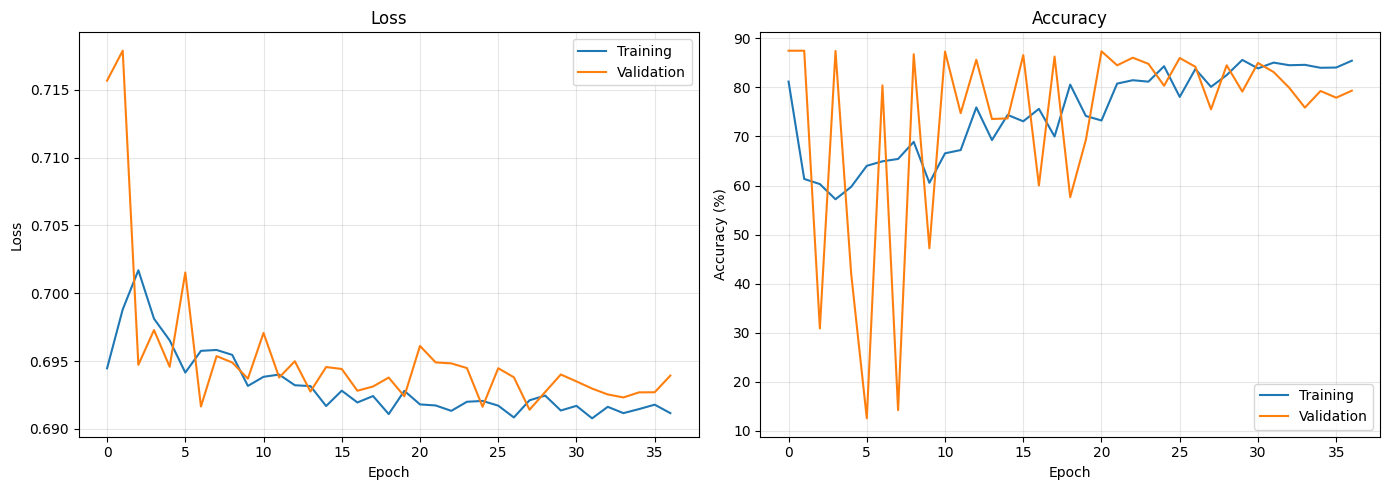

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label="Training")
axes[0].plot(val_losses, label="Validation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(np.array(train_accs) * 100, label="Training")
axes[1].plot(np.array(val_accs) * 100, label="Validation")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 10. Save temporal trajectories for the next stage (evidence accumulation / DDM)


In [13]:
trained_hidden_spikes = test_hidden_trace.cpu().numpy()
trained_output_spikes = test_output_trace.cpu().numpy()
trained_membrane = test_membrane_trace.cpu().numpy()

print("Hidden trajectory:  ", trained_hidden_spikes.shape)
print("Output trajectory:  ", trained_output_spikes.shape)
print("Membrane trajectory:", trained_membrane.shape)

print("\nNext stage: SNN spike trajectory -> evidence trajectory -> DDM (v, a, t0)")

Hidden trajectory:   (1680, 175, 64)
Output trajectory:   (1680, 175, 2)
Membrane trajectory: (1680, 175, 2)

Next stage: SNN spike trajectory -> evidence trajectory -> DDM (v, a, t0)
